# 03a — Vocabulaire de notes olfactives

Ce notebook construit le **vocabulaire de notes**, socle du futur moteur de
scoring Nayaar : à partir de `data/processed/nayaar_clean.csv` (colonne
`notes_list`), il extrait les notes uniques, les normalise, les regroupe en
12 familles olfactives, et leur attribue des scores métier (saison, moment,
profil).

**Entrée** : `data/processed/nayaar_clean.csv`

**Sortie** : `data/processed/notes_vocabulary.json` — fichier pensé pour être
**lu et corrigé à la main** (c'est de la connaissance métier probabiliste,
pas une vérité mesurée).

⚠️ Rappel `CLAUDE.md` : ces attributs sont produits par une heuristique
documentée (pas par GPT, pas par devinette silencieuse). Ils doivent être
validés avant d'entrer dans le moteur de scoring définitif.

Étapes :
1. Chargement et fréquence brute des notes
2. Normalisation des variantes d'écriture (mapping explicite)
3. Catégorisation en 12 familles olfactives
4. Notes non catégorisées → affichées pour traitement manuel
5. Attributs métier (saison / moment / profil) — moteur de règles explicite
6. Export vers `notes_vocabulary.json`
7. Visualisations : top 30 des notes, répartition par catégorie


In [1]:
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CHEMIN_DATASET_PROPRE = "../processed/nayaar_clean.csv"
CHEMIN_VOCABULAIRE = "../processed/notes_vocabulary.json"

# Seuil de fréquence en dessous duquel une note n'entre pas dans le
# vocabulaire structuré (catégorisation + scores). Choisi après inspection :
# sur 3257 notes uniques, 69% n'apparaissent qu'une fois et sont en grande
# partie du bruit de parsing (fragments de phrases). Un seuil de 5 couvre
# ~80% du volume total de notes tout en restant éditable à la main.
SEUIL_FREQUENCE = 5

sns.set_theme(style="whitegrid")


## 1. Chargement et fréquence brute des notes

In [2]:
df = pd.read_csv(CHEMIN_DATASET_PROPRE, encoding="utf-8")


def compter_notes_brutes(df):
    """
    Parcourt la colonne notes_list (sérialisée en JSON par le notebook 02)
    et compte la fréquence d'apparition de chaque note brute dans le dataset.
    """
    compteur = Counter()
    for valeur in df["notes_list"]:
        notes = json.loads(valeur)
        compteur.update(notes)
    return compteur


compteur_brut = compter_notes_brutes(df)
print(f"Notes uniques brutes : {len(compteur_brut)}")
print(f"Occurrences totales   : {sum(compteur_brut.values())}")
print("\nTop 10 brut :")
for note, occ in compteur_brut.most_common(10):
    print(f"  {occ:4d}  {note}")


Notes uniques brutes : 3257
Occurrences totales   : 18531

Top 10 brut :
   535  musk
   510  patchouli
   506  vanilla
   503  sandalwood
   502  bergamot
   462  amber
   363  rose
   362  jasmine
   328  vetiver
   296  cedar


## 2. Normalisation des variantes d'écriture

Mapping construit à partir d'une inspection réelle des notes brutes
(fréquences avant/après, variantes détectées par comparaison singulier/
pluriel et par recherche de motifs proches). Il couvre :

- des **pluriels** de la même matière (`roses` → `rose`) ;
- des **fautes/variantes d'orthographe** (`agardwood`, `agaroud`,
  `agarwoord` → `agarwood` ; `vetyver` → `vetiver`) ;
- des **artefacts de parsing** issus du notebook 02, quand la colonne
  `Notes` source contenait du texte libre mal découpé (`"and vanilla"` → `vanilla`) ;
- des **synonymes évidents** (`orange flower` = `orange blossom` ;
  `cassis` = `blackcurrant` ; `nagarmotha` = `cypriol`).

⚠️ Les variantes d'**origine géographique** (`bulgarian rose`, `cambodian
oud`, `sicilian bergamot`...) ne sont **volontairement pas fusionnées** :
ce sont de vraies nuances métier reconnues en parfumerie, pas des doublons
de saisie.

In [3]:
MAPPING_NORMALISATION = {
    "agar oud": "agarwood", "agar wood": "agarwood", "agardwood": "agarwood",
    "agaroud": "agarwood", "agarwoord": "agarwood", "agarwood (oud)": "agarwood",
    "musc": "musk", "muscs": "musk", "musk.": "musk", "musks": "musk",
    "vintage musks": "vintage musk",
    "roses": "rose", "lemons": "lemon", "tonka beans": "tonka bean",
    "violets": "violet", "ouds": "oud", "oudh": "oud", "white musks": "white musk",
    "orange blossoms": "orange blossom", "cloves": "clove", "clove bud": "clove",
    "clove buds": "clove", "oranges": "orange", "carnations": "carnation",
    "apples": "apple", "orange flowers": "orange flower", "freesias": "freesia",
    "figs": "fig", "cashmere woods": "cashmere wood", "green teas": "green tea",
    "ambrette seeds": "ambrette seed", "pink peppercorns": "pink peppercorn",
    "orris roots": "orris root", "carrot seeds": "carrot seed", "carrot": "carrot seed",
    "angelica roots": "angelica root", "vanilla pods": "vanilla pod",
    "vanilla pod": "vanilla", "vanilla bean": "vanilla", "and vanilla": "vanilla",
    "vanilla.": "vanilla", "blackcurrant buds": "blackcurrant bud",
    "everlasting flowers": "everlasting flower", "everlasting flower": "immortelle",
    "mushrooms": "mushroom", "tobacco flowers": "tobacco flower",
    "kaffir limes": "kaffir lime", "coriander seeds": "coriander seed",
    "coriander seed": "coriander", "celery seeds": "celery seed",
    "cumin seeds": "cumin seed", "cumin seed": "cumin", "grapes": "grape",
    "angelica seeds": "angelica seed", "indonesian cloves": "indonesian clove",
    "aldehyde": "aldehydes", "amber wood": "amberwood", "amber woods": "amberwood",
    "amber gris": "ambergris", "dry wood": "dry woods",
    "patchouly": "patchouli", "patchouli.": "patchouli",
    "vetyver": "vetiver", "vetiver root": "vetiver", "vetiver roots": "vetiver",
    "jasmin": "jasmine", "jasmin sambac": "jasmine sambac",
    "sambac jasmine": "jasmine sambac", "mandarine": "mandarin",
    "petit grain": "petitgrain", "oak moss": "oakmoss",
    "gaiac": "guaiac wood", "guaiac": "guaiac wood", "gaiac wood": "guaiac wood",
    "guaiacwood": "guaiac wood", "hinoki wood": "hinoki",
    "ylang-ylang": "ylang ylang", "ylang": "ylang ylang", "tonka": "tonka bean",
    "sandalwood.": "sandalwood", "cedarwood": "cedar", "cedar wood": "cedar",
    "coffee beans": "coffee bean", "coffee bean": "coffee",
    "saffron flowers": "saffron flower", "dates": "date", "bays": "bay",
    "cassis": "blackcurrant", "oppoponax": "opoponax", "nagarmotha": "cypriol",
    "orange flower": "orange blossom", "black currant": "blackcurrant",
}

# Termes trop génériques pour être de vraies notes (mots-valises utilisés par
# certaines fiches au lieu de nommer une matière précise) : on les exclut du
# vocabulaire structuré plutôt que de leur inventer une catégorie/des scores.
TERMES_VAGUES = {
    "wood", "woods", "spice", "spices", "resin", "resins", "floral", "florals",
    "green note", "green notes", "fruity note", "fruity notes", "woody accord",
    "woody accords", "marine notes", "citrus notes", "floral notes",
    "dried fruit", "dried fruits", "precious wood", "precious woods",
    "white flower", "white flowers", "berries", "fruit", "fruits", "fruity",
    "citrus", "smoke", "musk notes", "spice note", "leather accord",
    "woody notes", "grass", "hay",
}


def normaliser_compteur(compteur_brut, mapping):
    """Fusionne les variantes d'écriture d'une même note et ré-agrège les fréquences."""
    compteur_normalise = Counter()
    for note, occurrences in compteur_brut.items():
        canonique = mapping.get(note, note)
        compteur_normalise[canonique] += occurrences
    return compteur_normalise


compteur_normalise = normaliser_compteur(compteur_brut, MAPPING_NORMALISATION)

vocabulaire_brut = {
    note: occ for note, occ in compteur_normalise.items()
    if occ >= SEUIL_FREQUENCE and note not in TERMES_VAGUES
}

print(f"Notes uniques après normalisation : {len(compteur_normalise)}")
print(f"Vocabulaire retenu (>= {SEUIL_FREQUENCE} occurrences, hors termes vagues) : {len(vocabulaire_brut)}")


Notes uniques après normalisation : 3171
Vocabulaire retenu (>= 5 occurrences, hors termes vagues) : 333


## 3. Catégorisation en 12 familles olfactives

Construite à la main à partir de connaissances standard de parfumerie
(chaque note du vocabulaire est rattachée à une des 12 familles demandées).
Toute note qui ne figure dans aucune liste ci-dessous tombera dans
`notes_non_categorisees` (section suivante) — rien n'est catégorisé par
défaut/au hasard.

In [4]:
CATEGORIES = {
    "agrumes": [
        "lemon", "sicilian lemon", "italian lemon", "grapefruit", "pink grapefruit",
        "orange", "bitter orange", "sweet orange", "blood orange", "bigarade",
        "mandarin", "mandarin orange", "green mandarin", "sicilian mandarin",
        "red mandarin", "tangerine", "clementine", "lime", "yuzu", "pomelo",
        "bergamot", "italian bergamot", "calabrian bergamot", "sicilian bergamot",
        "petitgrain", "cedrat", "citron",
    ],
    "floral": [
        "jasmine", "jasmine sambac", "jasmine absolute", "jasmin de grasse",
        "egyptian jasmine", "rose", "bulgarian rose", "turkish rose", "damask rose",
        "white rose", "moroccan rose", "rose de mai", "rose absolute",
        "rose essence", "rose otto", "rose oil", "rose oxide", "rose petals",
        "taif rose", "iris", "orris", "orris root", "orris butter",
        "florentine iris", "violet", "violet leaf", "violet leaves", "tuberose",
        "tuberose absolute", "indian tuberose", "ylang ylang", "magnolia",
        "gardenia", "tahitian gardenia", "carnation", "freesia", "mimosa",
        "narcissus", "muguet", "lily of the valley", "lily", "water lily",
        "white lily", "orchid", "frangipani", "hyacinth", "honeysuckle", "lilac",
        "wisteria", "plumeria", "tiare", "champaca", "cyclamen", "marigold",
        "linden blossom", "cherry blossom", "peach blossom", "orange blossom",
        "orange blossom absolute", "neroli", "tunisian neroli", "moroccan neroli",
        "geranium", "geranium bourbon", "bourbon geranium", "hedione",
        "tobacco flower", "tulip", "broom", "osmanthus", "osmanthus absolute",
        "peony", "hawthorn", "lotus", "pittosporum", "aldehydes", "clover",
    ],
    "boise": [
        "sandalwood", "indian sandalwood", "mysore sandalwood", "australian sandalwood",
        "cedar", "atlas cedar", "atlas cedarwood", "white cedar", "virginia cedar",
        "moroccan cedarwood", "cashmere wood", "amberwood", "oakwood",
        "guaiac wood", "birch", "oak", "hinoki", "rosewood", "mahogany", "teak",
        "ebony", "pepperwood", "blonde woods", "palo santo", "gurjum", "cabreuva",
        "vetiver", "haitian vetiver", "java vetiver", "patchouli",
        "indonesian patchouli", "indian patchouli", "tunisian patchouli",
        "patchouli from indonesia", "agarwood", "oud", "cambodian oud",
        "akigalawood", "javanol", "iso e super", "cypriol", "dry woods",
        "carrot seed", "amyris",
    ],
    "epice": [
        "cardamom", "saffron", "saffron flower", "cinnamon", "pink pepper",
        "pink peppercorn", "nutmeg", "black pepper", "pepper", "red pepper",
        "white pepper", "clove", "indonesian clove", "ginger", "cumin",
        "coriander", "sichuan pepper", "star anise", "anise", "licorice",
        "caraway", "turmeric", "pimento", "calamus", "fennel", "elemi",
    ],
    "oriental_ambre": [
        "amber", "ambergris", "grey amber", "black amber", "white amber",
        "labdanum", "labdanum absolute", "cistus", "cistus labdanum",
        "benzoin", "benzoin resin", "siamese benzoin", "tolu", "tolu balsam",
        "peru balsam", "fir balsam", "balsam", "styrax", "opoponax",
        "olibanum", "frankincense", "incense", "myrrh", "ambroxan", "ambrox",
        "cetalox", "cashmeran",
    ],
    "aromatique": [
        "lavender", "sage", "clary sage", "thyme", "basil", "rosemary", "mint",
        "peppermint", "spearmint", "eucalyptus", "artemisia", "wormwood",
        "laurel", "bay", "bay leaf", "chamomile", "verbena", "mastic", "shiso",
        "oregano", "tarragon", "angelica", "angelica root", "angelica seed",
        "davana", "mate", "green tea", "black tea", "tea", "jasmine tea",
        "absinthe", "camphor", "lemongrass",
    ],
    "fruite": [
        "peach", "apricot", "pear", "plum", "prune", "apple", "green apple",
        "red apple", "blackcurrant", "blackcurrant bud", "raspberry",
        "blackberry", "red berries", "pink berries", "strawberry", "blueberry",
        "cherry", "pineapple", "mango", "lychee", "banana", "watermelon",
        "melon", "pomegranate", "quince", "fig", "date", "grape", "red currant",
        "white peach",
    ],
    "gourmand": [
        "vanilla", "tahitian vanilla", "bourbon vanilla", "madagascar vanilla",
        "vanilla absolute", "tonka bean", "tonka bean absolute", "coumarin",
        "caramel", "praline", "whipped cream", "dark chocolate", "chocolate",
        "cacao", "cocoa", "coffee", "coffee absolute", "milk", "coconut milk",
        "coconut", "sugar", "sugar cane", "honey", "white honey", "beeswax",
        "almond", "bitter almond", "rice powder", "rum", "whiskey", "cognac",
        "gin", "heliotrope", "immortelle", "hazelnut",
    ],
    "musque": [
        "musk", "white musk", "vintage musk", "ambrette", "ambrette seed",
        "civet", "costus", "enigmatic musks",
    ],
    "vert": [
        "oakmoss", "moss", "tree moss", "galbanum", "green leaves", "fig leaf",
        "fern", "rhubarb", "pine", "pine needles", "fir", "juniper",
        "juniper berry", "juniper berries", "myrtle", "celery seed", "papyrus",
        "cypress", "mushroom",
    ],
    "aquatique": [
        "calone", "sea salt", "seaweed",
    ],
    "cuir": [
        "leather", "suede", "castoreum", "ash", "cade", "birch tar", "tobacco",
        "tobacco leaf",
    ],
}

# Notes catégorisées mais dont le choix de famille est plus discutable
# (matières de synthèse récentes, notes à cheval sur plusieurs familles).
# Elles reçoivent quand même une catégorie (mieux qu'une absence), mais
# marquées "confiance faible" dans le JSON pour une revue manuelle prioritaire.
NOTES_INCERTAINES = {
    "iso e super", "javanol", "ambroxan", "ambrox", "cetalox", "cashmeran",
    "hedione", "davana", "elemi", "costus", "akigalawood", "gurjum",
    "cabreuva", "mastic", "broom", "calone", "aldehydes", "heliotrope",
    "immortelle", "carrot seed", "amyris", "enigmatic musks", "clover",
}


def construire_index_categories(categories):
    """
    Inverse le dict {catégorie: [notes]} en {note: catégorie}, avec un
    garde-fou : si une note apparaît dans deux catégories (erreur de saisie),
    on arrête tout de suite plutôt que de catégoriser silencieusement au hasard.
    """
    index = {}
    for categorie, notes in categories.items():
        for note in notes:
            if note in index:
                raise ValueError(f"Note en double : {note} ({index[note]} / {categorie})")
            index[note] = categorie
    return index


note_vers_categorie = construire_index_categories(CATEGORIES)


## 4. Notes non catégorisées (à traiter manuellement)

In [5]:
notes_non_categorisees = {
    note: occ for note, occ in vocabulaire_brut.items()
    if note not in note_vers_categorie
}

print(f"Notes du vocabulaire sans catégorie assignée : {len(notes_non_categorisees)}")
for note, occ in sorted(notes_non_categorisees.items(), key=lambda x: -x[1]):
    print(f"  {occ:4d}  {note}")

if not notes_non_categorisees:
    print("(aucune — toutes les notes du vocabulaire ont une catégorie ;")
    print(" voir malgré tout la liste 'confiance faible' dans le JSON exporté)")


Notes du vocabulaire sans catégorie assignée : 0
(aucune — toutes les notes du vocabulaire ont une catégorie ;
 voir malgré tout la liste 'confiance faible' dans le JSON exporté)


## 5. Attributs métier (saison / moment / profil)

Moteur de règles **explicite et auditable** : une base de scores par
catégorie olfactive (jugement de parfumerie standard — ex. agrumes = plutôt
été/jour/unisexe, cuir = plutôt hiver/nuit/masculin), affinée par de légers
ajustements selon des mots-clés présents dans le nom de la note.

C'est une heuristique, pas une mesure. Chaque note exportée porte
`"attributs_heuristiques": true` et un niveau de confiance, pour rappeler
qu'une validation manuelle est nécessaire avant utilisation dans le moteur
de scoring (règle métier absolue de `CLAUDE.md` : l'IA ne décide jamais
seule).

In [6]:
BASE_PAR_CATEGORIE = {
    # saisons                                    moment                profil
    "agrumes":        dict(winter=0.3, spring=0.7, summer=0.9, autumn=0.4, day=0.8, night=0.3, masculine=0.5, feminine=0.5, unisex=0.9),
    "floral":          dict(winter=0.3, spring=0.9, summer=0.6, autumn=0.4, day=0.7, night=0.5, masculine=0.2, feminine=0.9, unisex=0.4),
    "boise":           dict(winter=0.7, spring=0.4, summer=0.3, autumn=0.7, day=0.4, night=0.8, masculine=0.7, feminine=0.3, unisex=0.6),
    "epice":           dict(winter=0.7, spring=0.4, summer=0.4, autumn=0.7, day=0.4, night=0.8, masculine=0.6, feminine=0.4, unisex=0.6),
    "oriental_ambre":  dict(winter=0.8, spring=0.3, summer=0.2, autumn=0.7, day=0.3, night=0.9, masculine=0.5, feminine=0.5, unisex=0.6),
    "aromatique":      dict(winter=0.4, spring=0.7, summer=0.7, autumn=0.4, day=0.8, night=0.3, masculine=0.6, feminine=0.3, unisex=0.8),
    "fruite":          dict(winter=0.2, spring=0.7, summer=0.8, autumn=0.5, day=0.7, night=0.3, masculine=0.2, feminine=0.8, unisex=0.5),
    "gourmand":        dict(winter=0.8, spring=0.3, summer=0.2, autumn=0.7, day=0.3, night=0.8, masculine=0.3, feminine=0.7, unisex=0.5),
    "musque":          dict(winter=0.6, spring=0.5, summer=0.5, autumn=0.6, day=0.5, night=0.7, masculine=0.5, feminine=0.5, unisex=0.9),
    "vert":            dict(winter=0.3, spring=0.8, summer=0.6, autumn=0.4, day=0.8, night=0.3, masculine=0.6, feminine=0.4, unisex=0.8),
    "aquatique":       dict(winter=0.2, spring=0.6, summer=0.9, autumn=0.3, day=0.8, night=0.2, masculine=0.5, feminine=0.5, unisex=0.9),
    "cuir":            dict(winter=0.7, spring=0.2, summer=0.2, autumn=0.6, day=0.2, night=0.9, masculine=0.8, feminine=0.2, unisex=0.4),
}

# Ajustements par mot-clé, appliqués par-dessus la base de catégorie.
AJUSTEMENTS_MOTS_CLES = [
    (["white", "blossom", "fresh", "green apple"], dict(day=+0.1, summer=+0.1, night=-0.1)),
    (["dark", "black", "smoke", "tar", "absolute"], dict(night=+0.1, winter=+0.1, day=-0.1)),
]


def calculer_attributs(note, categorie):
    """
    Calcule les scores saison / moment / profil d'une note à partir de la
    base de sa catégorie olfactive, ajustée par mots-clés. Estimation de
    style heuristique — pas un calcul mesuré — à valider avant intégration
    au moteur de scoring.
    """
    base = dict(BASE_PAR_CATEGORIE[categorie])
    for mots, ajustements in AJUSTEMENTS_MOTS_CLES:
        if any(mot in note for mot in mots):
            for cle, delta in ajustements.items():
                base[cle] = min(1.0, max(0.0, base[cle] + delta))

    return {
        "saisons": {cle: round(base[cle], 2) for cle in ["winter", "spring", "summer", "autumn"]},
        "moment": {cle: round(base[cle], 2) for cle in ["day", "night"]},
        "profil": {cle: round(base[cle], 2) for cle in ["masculine", "feminine", "unisex"]},
    }


## 6. Export vers `notes_vocabulary.json`

In [7]:
notes_json = {}
for note, occurrences in sorted(vocabulaire_brut.items(), key=lambda x: -x[1]):
    if note not in note_vers_categorie:
        continue
    categorie = note_vers_categorie[note]
    notes_json[note] = {
        "frequence": occurrences,
        "categorie": categorie,
        "attributs_heuristiques": True,
        "confiance_categorisation": "faible" if note in NOTES_INCERTAINES else "haute",
        **calculer_attributs(note, categorie),
    }

vocabulaire_json = {
    "metadata": {
        "version": "1.0",
        "source": "data/processed/nayaar_clean.csv",
        "nb_parfums_analyses": len(df),
        "seuil_frequence_minimum": SEUIL_FREQUENCE,
        "nb_notes_uniques_brutes": len(compteur_brut),
        "nb_notes_uniques_apres_normalisation": len(compteur_normalise),
        "nb_notes_vocabulaire": len(notes_json),
        "nb_notes_non_categorisees": len(notes_non_categorisees),
        "avertissement": (
            "Les champs saisons/moment/profil sont des estimations heuristiques "
            "(regles par categorie + mots-cles), PAS des donnees mesurees. "
            "Conformement a CLAUDE.md, elles doivent etre validees manuellement "
            "avant utilisation dans le moteur de scoring - l'IA ne decide "
            "jamais seule d'une recommandation."
        ),
    },
    "categories": sorted(CATEGORIES.keys()),
    "mapping_normalisation": MAPPING_NORMALISATION,
    "termes_vagues_exclus": sorted(TERMES_VAGUES),
    "notes": notes_json,
    "notes_non_categorisees": [
        {"note": note, "frequence": occ}
        for note, occ in sorted(notes_non_categorisees.items(), key=lambda x: -x[1])
    ],
}

with open(CHEMIN_VOCABULAIRE, "w", encoding="utf-8") as f:
    json.dump(vocabulaire_json, f, ensure_ascii=False, indent=2)

print(f"Vocabulaire exporte : {CHEMIN_VOCABULAIRE}")
print(f"  {len(notes_json)} notes categorisees")
print(f"  dont {sum(1 for v in notes_json.values() if v['confiance_categorisation']=='faible')} a confiance faible (a verifier en priorite)")


Vocabulaire exporte : ../processed/notes_vocabulary.json
  333 notes categorisees
  dont 23 a confiance faible (a verifier en priorite)


## 7. Visualisations

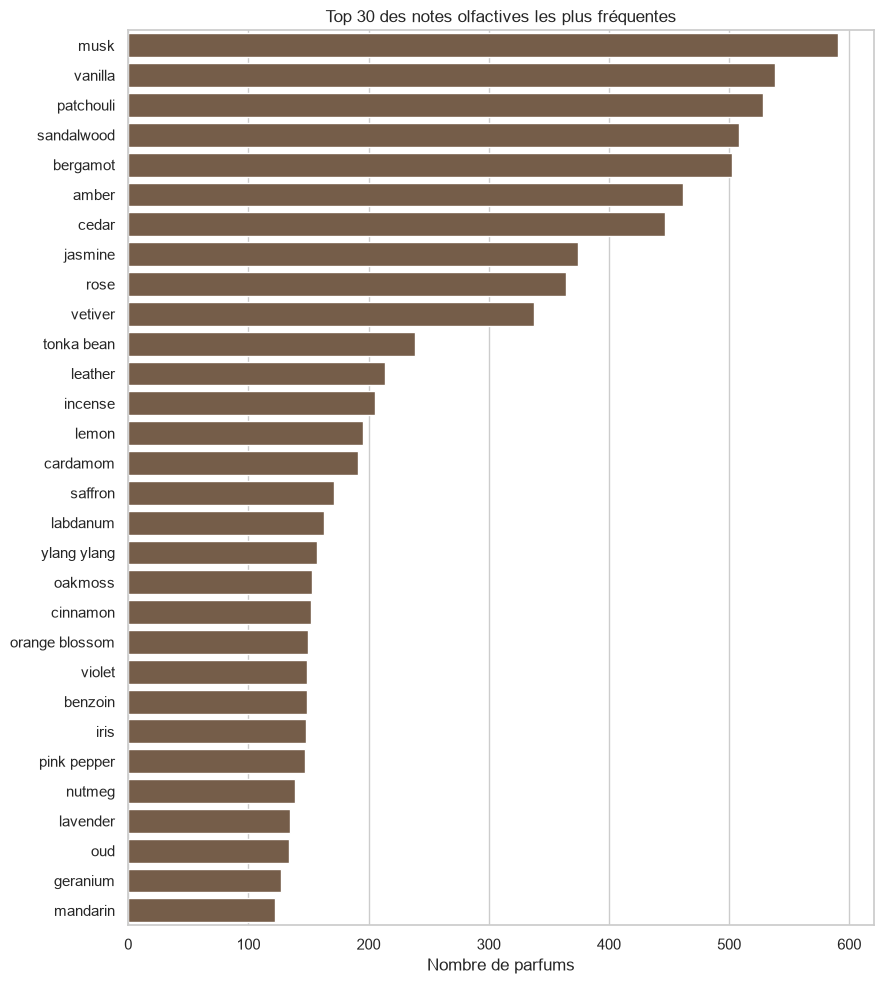

In [8]:
# Top 30 des notes les plus fréquentes (sur le vocabulaire normalisé)
top30 = sorted(vocabulaire_brut.items(), key=lambda x: -x[1])[:30]
noms = [n for n, _ in top30]
frequences = [c for _, c in top30]

fig, ax = plt.subplots(figsize=(9, 10))
sns.barplot(x=frequences, y=noms, ax=ax, color="#7c5c42")
ax.set_title("Top 30 des notes olfactives les plus fréquentes")
ax.set_xlabel("Nombre de parfums")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


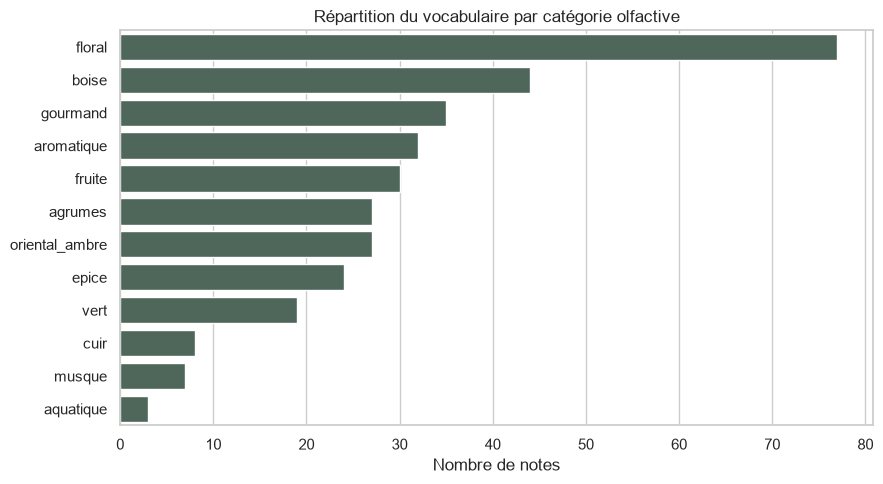

In [9]:
# Répartition des notes du vocabulaire par catégorie olfactive
repartition = Counter(note_vers_categorie[n] for n in vocabulaire_brut if n in note_vers_categorie)
categories_triees = sorted(repartition.items(), key=lambda x: -x[1])
noms_cat = [c for c, _ in categories_triees]
effectifs = [n for _, n in categories_triees]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=effectifs, y=noms_cat, ax=ax, color="#4a6b5a")
ax.set_title("Répartition du vocabulaire par catégorie olfactive")
ax.set_xlabel("Nombre de notes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
